---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 12. Оптоелектронні прилади</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Поглинання світла в напівпровідниках, внутрішній фотоефект</li>
  <li>Фоторезистори: конструкція, характеристики, застосування</li>
  <li>Фотодіоди: фотодіодний і фотогальванічний режими, різновиди, сонячні елементи</li>
  <li>Світлодіоди: інжекційна електролюмінесценція, матеріали, конструкція</li>
  <li>Оптрони: типи, параметри, гальванічна розв'язка</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 12 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Поглинання світла і внутрішній фотоефект](#photoeffect)
* [Фоторезистори](#photoresistor)
    * [⚙️ PySpice: сутінковий вимикач на фоторезисторі](#spice-ldr)
* [Фотодіоди](#photodiode)
    * [⚙️ PySpice: ВАХ фотодіода при різній освітленості](#spice-pd-iv)
    * [⚙️ PySpice: сонячний елемент і точка максимальної потужності](#spice-solar)
    * [⚙️ PySpice: швидкодія фотодіода в фотодіодному режимі](#spice-pd-speed)
* [Світлодіоди](#led)
    * [⚙️ PySpice: ВАХ світлодіодів різних кольорів](#spice-led)
* [Оптрони](#optocoupler)
    * [⚙️ PySpice: транзисторний оптрон — CTR і швидкодія](#spice-opto)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

h_P, c_light = 6.62607015e-34, 2.99792458e8
def wavelength_um(Eg_eV):
    """Червона межа фотоефекту / довжина хвилі випромінювання, мкм: λ = hc/E ≈ 1,24/E[еВ]"""
    return h_P*c_light/(Eg_eV*q)*1e6

def add_photodiode(c, name, anode, cathode, I_ph, area=1.0, model='PD'):
    """Фотодіод: діод + паралельне джерело фотоструму (фотострум тече від катода до анода всередині приладу)."""
    c.D(name, anode, cathode, model=model)
    c.I('ph' + name, cathode, anode, I_ph)    # I(n+, n-): усередині джерела струм тече n+ -> n-, тобто з катода в анод

---

# Поглинання світла і внутрішній фотоефект <a class="anchor" id="photoeffect"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати внутрішній фотоефект і визначати червону межу фоточутливості матеріалу
> - Описувати конструкцію, принцип дії, характеристики й застосування фоторезисторів
> - Розрізняти фотодіодний і фотогальванічний режими фотодіода, різновиди фотодіодів
> - Розраховувати напругу холостого ходу, струм КЗ і точку максимальної потужності сонячного елемента
> - Пояснювати принцип дії, матеріали та конструкцію світлодіодів
> - Класифікувати оптрони, визначати коефіцієнт передачі струму (CTR) і пояснювати гальванічну розв'язку

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Внутрішній фотоефект** | Генерація електронно-діркових пар у напівпровіднику при поглинанні фотонів з енергією $h\nu \ge E_g$ |
| **Червона межа $\lambda_{гр}$** | Найбільша довжина хвилі, що ще спричиняє фотоефект: $\lambda_{гр} = hc/E_g \approx 1{,}24/E_g$[еВ] мкм |
| **Струмова чутливість $S_I$** | Відношення фотоструму до потужності (або світлового потоку) падаючого випромінювання, А/Вт (А/лм) |
| **Інжекційна електролюмінесценція** | Випромінювання світла при рекомбінації носіїв, інжектованих через прямо зміщений p-n перехід |
| **Оптрон** | Прилад з випромінювачем і фотоприймачем в одному корпусі, оптично зв'язаними і електрично ізольованими |
| **CTR** | Коефіцієнт передачі струму оптрона: $I_{вих}/I_{вх}$, % |

Фотон з енергією $E_ф = h\nu = hc/\lambda$ поглинається напівпровідником, якщо $h\nu \ge E_g$: електрон переходить з валентної зони в зону провідності, утворюється **електронно-діркова пара** — це **внутрішній фотоефект** (на відміну від зовнішнього, при якому електрон вилітає з речовини). Звідси **червона межа** фоточутливості:

$$\lambda_{гр} = \frac{hc}{E_g} \approx \frac{1{,}24}{E_g\,[\text{еВ}]}\ \text{мкм}.$$

Інтенсивність світла спадає вглиб матеріалу за законом Бугера–Ламберта $\Phi(x) = \Phi_0 e^{-\alpha x}$. У **прямозонних** напівпровідниках (GaAs, InGaAs, CdS) коефіцієнт поглинання $\alpha$ одразу за краєм зони сягає $10^4$–$10^5$ см⁻¹ (світло поглинається на глибині ~1 мкм); у **непрямозонному** кремнії поглинання потребує участі фонона, тому $\alpha$ зростає повільно, і ІЧ-світло проникає на десятки–сотні мкм. На короткохвильовому боці чутливість обмежує поверхнева рекомбінація: світло поглинається в тонкому приповерхневому шарі, де носії швидко гинуть.

Фотоприймачі: **фоторезистори** (фотопровідність), **фотодіоди** і **фототранзистори** (поділ пар полем p-n переходу), **фототиристори**, матричні приймачі (ПЗЗ і КМОН, Лекція 13). Випромінювачі: **світлодіоди** і **лазерні діоди**.

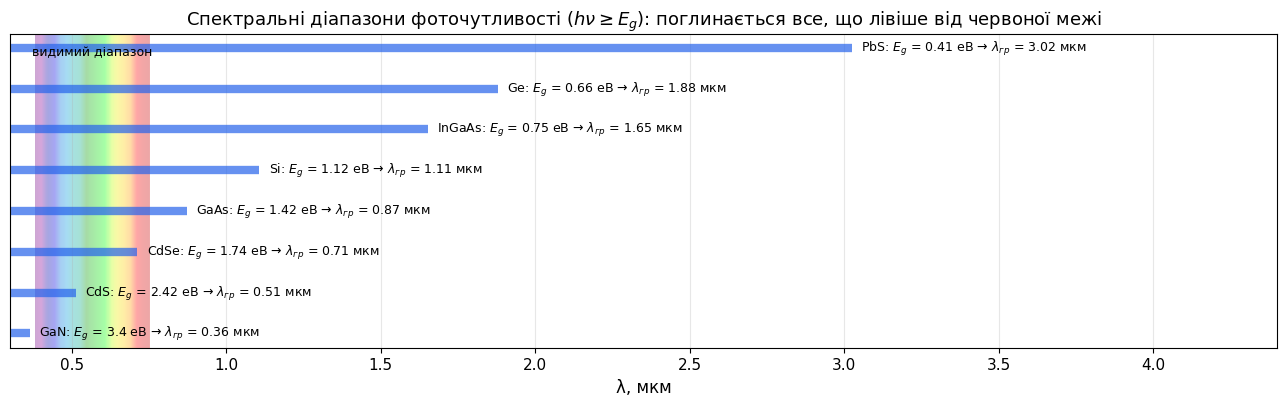

In [2]:
materials = [('Ge', 0.66), ('Si', 1.12), ('GaAs', 1.42), ('CdSe', 1.74), ('CdS', 2.42), ('GaN', 3.4), ('InGaAs', 0.75), ('PbS', 0.41)]
fig, ax = plt.subplots(figsize=(13, 4.2))
lam = np.linspace(0.3, 3.2, 600)
cmap_vis = plt.get_cmap('nipy_spectral')
for l0 in np.linspace(0.38, 0.75, 120):
    ax.axvspan(l0, l0 + 0.0031, color=cmap_vis((l0 - 0.38)/0.37*0.9 + 0.05), alpha=0.35, lw=0)
ax.text(0.565, 0.93, 'видимий діапазон', ha='center', transform=ax.get_xaxis_transform(), fontsize=9)
for k, (name, Eg) in enumerate(sorted(materials, key=lambda m: -m[1])):
    lg = wavelength_um(Eg)
    ax.plot([0.3, lg], [k, k], lw=6, color='#2563eb', alpha=0.7, solid_capstyle='butt')
    ax.text(lg + 0.03, k, f'{name}: $E_g$ = {Eg} еВ → $\\lambda_{{гр}}$ = {lg:.2f} мкм', va='center', fontsize=9)
ax.set_yticks([]); ax.set_xlim(0.3, 4.4); ax.set_xlabel('λ, мкм')
ax.set_title('Спектральні діапазони фоточутливості ($h\\nu \\geq E_g$): поглинається все, що лівіше від червоної межі')
plt.tight_layout(); plt.show()

---

# Фоторезистори <a class="anchor" id="photoresistor"></a>

**Фоторезистор** — напівпровідниковий резистор, опір якого зменшується під дією світла (ефект **фотопровідності**). p-n переходу він не має і однаково працює при будь-якій полярності напруги.

**Конструкція.** На ізолюючу (керамічну, скляну) підкладку наносять тонкий шар фоточутливого напівпровідника — **CdS** (максимум чутливості 0,52 мкм — як у людського ока), **CdSe** (0,72 мкм), **PbS**, **PbSe**, **InSb** (ІЧ-діапазон 1–5 мкм). Зверху — **гребінчасті (зустрічно-штирьові) електроди**: довгий звивистий проміжок малої ширини дає велике відношення ширини до довжини провідного каналу, а отже малий опір при освітленні. Шар захищають лаком або скляним вікном (корпуси GL55xx, ФСК-1, СФ2).

**Принцип дії.** Світло генерує надлишкові носії зі швидкістю $G = \eta\alpha\Phi/(h\nu)$; в усталеному стані їх концентрація $\Delta n = G\tau$, де $\tau$ — час життя. Провідність зростає на

$$\Delta\sigma = q(\mu_n\Delta n + \mu_p\Delta p).$$

**Фотострумове підсилення**: за час життя $\tau$ носій може багато разів пройти між електродами (час прольоту $t_{пр} = L^2/(\mu U)$), тому $K = \tau/t_{пр}$ сягає $10^3$–$10^5$ — фоторезистори дуже чутливі, але й **інерційні**: та сама велика $\tau$ дає часи наростання/спаду від одиниць до сотень мілісекунд.

**Характеристики і параметри:**

- **темновий опір** $R_т$ (1–100 МОм) і **світловий** $R_с$ при 10 лк (1–100 кОм); кратність $R_т/R_с$ — до $10^4$–$10^6$;
- **люкс-омна характеристика** — степенева: $R(E) = R_{10}(E/10\ \text{лк})^{-\gamma}$, $\gamma$ = 0,5–1;
- **спектральна характеристика**, вольт-амперна (лінійна — це резистор), допустима потужність розсіювання і напруга;
- **постійні часу** наростання і спаду фотоструму.

**Переваги:** висока чутливість, простота, робота на змінному струмі, дешевизна. **Недоліки:** велика інерційність, нелінійність, температурна нестабільність, «пам'ять» (залежність від попереднього освітлення); CdS-фоторезистори обмежено директивою RoHS (кадмій).

**Застосування:** датчики освітленості (сутінкові вимикачі вуличного освітлення, автоматичне регулювання яскравості дисплеїв), фотореле, експонометри, вимірювачі ІЧ-випромінювання (PbS, PbSe — газоаналізатори, піротехніка), резисторні оптрони (аналогові регулятори, компресори гітарних ефектів).

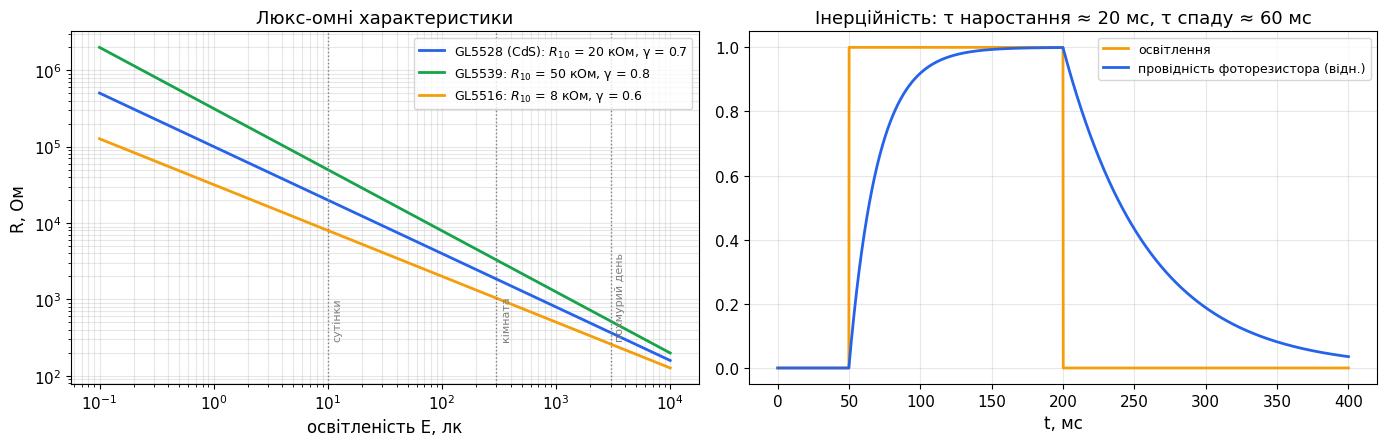

In [3]:
E_lux = np.logspace(-1, 4, 300)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for R10, gamma, name, col in [(20e3, 0.7, 'GL5528 (CdS)', '#2563eb'), (50e3, 0.8, 'GL5539', '#16a34a'), (8e3, 0.6, 'GL5516', '#f59e0b')]:
    R = np.minimum(R10*(E_lux/10)**(-gamma), 1e6 if name == 'GL5516' else 2e6)
    axes[0].loglog(E_lux, R, color=col, label=f'{name}: $R_{{10}}$ = {R10/1e3:.0f} кОм, γ = {gamma}')
axes[0].set_xlabel('освітленість E, лк'); axes[0].set_ylabel('R, Ом'); axes[0].set_title('Люкс-омні характеристики')
axes[0].legend(fontsize=9); axes[0].grid(True, which='both', alpha=0.3)
for lab, x in [('сутінки', 10), ('кімната', 300), ('похмурий день', 3000)]:
    axes[0].axvline(x, color='gray', ls=':', lw=1); axes[0].text(x*1.1, 3e2, lab, rotation=90, fontsize=8, color='gray')
# інерційність: відгук на світловий імпульс
t = np.linspace(0, 400, 2000)    # мс
tau_on, tau_off = 20, 60
light = (t > 50) & (t < 200)
g = np.zeros_like(t)
for k in range(1, len(t)):
    tau = tau_on if light[k] else tau_off
    g[k] = g[k-1] + ((1.0 if light[k] else 0.0) - g[k-1])*(t[k] - t[k-1])/tau
axes[1].plot(t, light.astype(float), color='#f59e0b', label='освітлення')
axes[1].plot(t, g, color='#2563eb', label='провідність фоторезистора (відн.)')
axes[1].set_xlabel('t, мс'); axes[1].set_title(f'Інерційність: τ наростання ≈ {tau_on} мс, τ спаду ≈ {tau_off} мс'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### ⚙️ PySpice: сутінковий вимикач на фоторезисторі <a class="anchor" id="spice-ldr"></a>

Фоторезистор GL5528 і резистор $R_1$ утворюють дільник; коли стає темно, опір фоторезистора зростає, напруга на базі транзистора 2N3904 перевищує ≈ 0,65 В, транзистор відкривається і вмикає світлодіод (або реле вуличного ліхтаря). $R_1$ задає поріг спрацювання. Опір фоторезистора для кожного рівня освітленості обчислюється за люкс-омною характеристикою, і для кожного значення ngspice розраховує робочу точку.

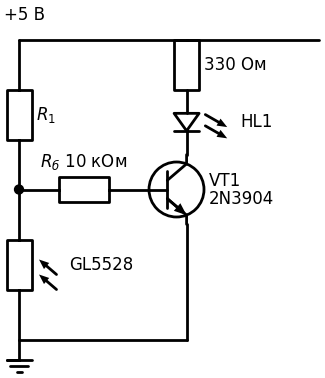

In [4]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        d.add(elm.Line().endpoints((0, 6), (6, 6))); d.add(elm.Label().at((0, 6.4)).label('+5 В'))
        d.add(elm.Resistor().endpoints((0, 6), (0, 3)).label('$R_1$', loc='bottom'))
        d.add(elm.Dot().at((0, 3)))
        d.add(elm.Photoresistor().endpoints((0, 3), (0, 0)).label('GL5528', loc='bottom'))
        d.add(elm.Resistor().endpoints((0, 3), (2.6, 3)).label('$R_б$ 10 кОм'))
        q1 = d.add(elm.BjtNpn(circle=True).anchor('base').at((2.6, 3)).label('VT1\n2N3904', loc='right'))
        d.add(elm.Line().at(q1.emitter).toy(0))
        d.add(elm.LED().endpoints((q1.collector[0], 5.0), q1.collector).label('HL1', loc='bottom'))
        d.add(elm.Resistor().endpoints((q1.collector[0], 6), (q1.collector[0], 5.0)).label('330 Ом', loc='bottom'))
        d.add(elm.Line().endpoints((0, 0), (q1.emitter[0], 0))); d.add(elm.Ground().at((0, 0)))

In [5]:
def twilight_switch(R1_kOhm=47):
    R10, gamma = 20e3, 0.7
    E_list = np.logspace(-1, 3, 50)
    U_b, I_led = [], []
    for E in E_list:
        R_ldr = min(R10*(E/10)**(-gamma), 2e6)
        c = Circuit('Twilight switch'); c.include(lib('bjt')); c.include(lib('diodes'))
        c.V('cc', 'vcc', c.gnd, 5)
        c.R('1', 'vcc', 'div', R1_kOhm*1e3); c.R('ldr', 'div', c.gnd, R_ldr)
        c.R('b', 'div', 'b', 10e3); c.BJT(1, 'k', 'b', c.gnd, model='Q2N3904')
        c.R('c', 'vcc', 'led', 330); c.D('led', 'led', 'k', model='LED_RED')
        op = c.simulator().operating_point()
        U_b.append(float(op['div'][0])); I_led.append((5 - float(op['led'][0]))/330)
    U_b, I_led = np.array(U_b), np.array(I_led)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
    axes[0].semilogx(E_list, U_b, color='#2563eb'); axes[0].axhline(0.65, color='gray', ls=':')
    axes[0].set_xlabel('освітленість, лк'); axes[0].set_ylabel('U дільника, В'); axes[0].set_title('Напруга на виході дільника')
    axes[1].semilogx(E_list, np.array(I_led)*1e3, color='#dc2626')
    axes[1].set_xlabel('освітленість, лк'); axes[1].set_ylabel('$I_{HL1}$, мА'); axes[1].set_title(f'Струм світлодіода, $R_1$ = {R1_kOhm} кОм')
    for a in axes: a.grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    k = np.argmin(abs(I_led - I_led.max()/2))
    print(f'Поріг спрацювання (струм світлодіода — половина максимального): ≈ {E_list[k]:.1f} лк')

interact(twilight_switch, R1_kOhm=widgets.SelectionSlider(options=[10, 22, 47, 100, 220, 470], value=47,
                                                          description='$R_1$, кОм', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='$R_1$, кОм', index=2, options=(10,…

---

# Фотодіоди <a class="anchor" id="photodiode"></a>

**Фотодіод** — p-n перехід (або бар'єр Шотки), в якому електронно-діркові пари, згенеровані світлом в ОПЗ і на відстані дифузійної довжини від неї, розділяються вбудованим полем: електрони — в n-область, дірки — в p-область. Виникає **фотострум** $I_ф = S_I\Phi$, спрямований як **зворотний** струм діода. ВАХ освітленого фотодіода — це ВАХ діода, зсунута вниз на $I_ф$:

$$I = I_0\left(e^{U/m\varphi_T} - 1\right) - I_ф .$$

**Конструкція.** Кремнієвий кристал з тонким (0,3–1 мкм) освітлюваним p⁺-шаром, щоб світло доходило до переходу; просвітлююче покриття (SiO₂, Si₃N₄), металевий контакт по периметру; корпус з вікном або лінзою (BPW34, ФД-256, SFH203), матриці — у SMD-корпусах.

**Два режими роботи:**

1. **Фотодіодний (фотопровідний)** — зворотне зміщення від зовнішнього джерела (III квадрант ВАХ). Струм майже не залежить від напруги і **лінійно** залежить від світлового потоку в діапазоні 6–8 декад; зворотна напруга розширює ОПЗ, зменшує бар'єрну ємність і підвищує швидкодію. Темновий струм $I_0$ (наноампери) визначає поріг чутливості.
2. **Фотогальванічний (вентильний)** — без зовнішнього джерела (IV квадрант): фотодіод сам є **генератором ЕРС**. Напруга холостого ходу і струм короткого замикання:

$$U_{хх} = m\varphi_T\ln\left(\frac{I_ф}{I_0} + 1\right) \approx 0{,}4\ldots0{,}7\ \text{В (Si)}, \qquad I_{кз} = I_ф .$$

$U_{хх}$ зростає з освітленістю **логарифмічно**, $I_{кз}$ — **лінійно**. На цьому режимі працюють **сонячні елементи** — фотодіоди великої площі.

**Різновиди фотодіодів:**

| Тип | Особливість будови | Переваги | Застосування |
|---|---|---|---|
| **p-n** | дифузійний перехід | простота, мала темнова струм | фотометрія, датчики |
| **p-i-n** | широкий власний i-шар між p⁺ і n⁺ | мала ємність, світло поглинається в полі → швидкодія до ГГц, широкий спектр | оптичний зв'язок, ІЧ-пульти, лідари |
| **Лавинні (ЛФД, APD)** | зворотна напруга поблизу пробою, лавинне множення $M$ = 10–1000 | внутрішнє підсилення фотоструму | волоконно-оптичні лінії, лічильники фотонів |
| **З бар'єром Шотки** | тонкий напівпрозорий метал на напівпровіднику | чутливість в УФ, швидкодія | УФ-датчики (GaP, SiC, GaN) |
| **Гетероструктурні** | широкозонне «вікно» на вузькозонному поглиначі (InP/InGaAs) | чутливість на 1,3–1,55 мкм | волоконний зв'язок |
| **Фототранзистор** | фотодіод колектор–база + підсилення β | струм у 100–1000 разів більший | оптрони, датчики положення |

### ⚙️ PySpice: ВАХ фотодіода при різній освітленості <a class="anchor" id="spice-pd-iv"></a>

Модель: діод (кремнієвий фотодіод площею ≈ 7 мм², як BPW34) паралельно з джерелом фотоструму $I_ф = S_I\cdot P_{опт}$, $S_I$ = 0,6 А/Вт на 850 нм. Розгортка напруги від −5 до +0,6 В показує обидва робочі квадранти.

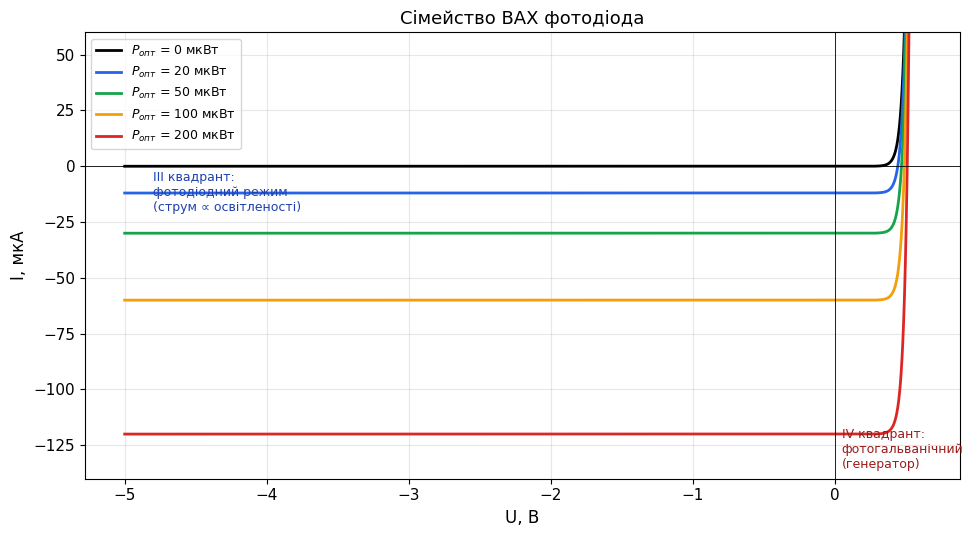

In [6]:
PD_MODEL = dict(IS=2e-12, N=1.1, RS=10, CJO=70e-12, VJ=0.7, M=0.5, BV=60, IBV=1e-6)
fig, ax = plt.subplots(figsize=(10, 5.5))
for P_uW, col in [(0, 'k'), (20, '#2563eb'), (50, '#16a34a'), (100, '#f59e0b'), (200, '#dc2626')]:
    c = Circuit('Photodiode IV'); c.model('PD', 'D', **PD_MODEL)
    c.V('d', 'a', c.gnd, 0)
    add_photodiode(c, '1', 'a', c.gnd, 0.6*P_uW*1e-6)
    an = c.simulator().dc(Vd=slice(-5, 0.6, 0.002))
    U, I = np.array(an.sweep), -np.array(an.branches['vd'])
    ax.plot(U, I*1e6, color=col, label=f'$P_{{опт}}$ = {P_uW} мкВт')
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
ax.set_ylim(-140, 60); ax.set_xlabel('U, В'); ax.set_ylabel('I, мкА')
ax.text(-4.8, -20, 'III квадрант:\nфотодіодний режим\n(струм ∝ освітленості)', fontsize=9, color='#1e40af')
ax.text(0.05, -135, 'IV квадрант:\nфотогальванічний\n(генератор)', fontsize=9, color='#991b1b')
ax.set_title('Сімейство ВАХ фотодіода'); ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

### ⚙️ PySpice: сонячний елемент і точка максимальної потужності <a class="anchor" id="spice-solar"></a>

Кремнієвий сонячний елемент 156×156 мм: $I_{кз}$ ≈ 9 А при освітленості 1000 Вт/м² (стандартні умови AM1.5), послідовний опір $R_s$ (контакти, сітка електродів) і шунтуючий $R_{ш}$ (витоки по краях). Навантаження — змінний опір; потужність $P = UI$ максимальна в **точці максимальної потужності** (MPP), на утримання якої налаштовані контролери MPPT. **Коефіцієнт заповнення** $FF = P_{max}/(U_{хх}I_{кз})$ — міра «прямокутності» ВАХ.

In [7]:
def solar_cell(G=1000, Rs_mOhm=5, Rsh=20, T=25):
    c = Circuit('Solar cell'); c.model('SC', 'D', IS=1e-9, N=1.2, EG=1.12, XTI=3)
    c.V('l', 'p', c.gnd, 0)
    c.D('1', 'j', c.gnd, model='SC'); c.I('ph', c.gnd, 'j', 9.0*G/1000)
    c.R('sh', 'j', c.gnd, Rsh); c.R('s', 'j', 'p', Rs_mOhm*1e-3)
    an = c.simulator(temperature=T, nominal_temperature=25).dc(Vl=slice(0, 0.75, 0.001))
    U, I = np.array(an.sweep), np.array(an.branches['vl'])          # струм у навантаження (позитивний)
    m = I >= 0; U, I = U[m], I[m]; P = U*I
    k = np.argmax(P); Uoc, Isc = U[-1], I[0]
    fig, ax = plt.subplots(figsize=(10, 5)); ax2 = ax.twinx()
    ax.plot(U, I, color='#2563eb', label='I(U)'); ax2.plot(U, P, color='#dc2626', label='P(U)')
    ax.plot(U[k], I[k], 'ko'); ax2.plot(U[k], P[k], 'ro')
    ax.fill_between([0, U[k]], 0, I[k], color='#bfdbfe', alpha=0.5)
    ax.annotate(f'MPP: {U[k]:.3f} В, {I[k]:.2f} А, {P[k]:.2f} Вт', (U[k], I[k]), xytext=(-220, -60), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'))
    ax.set_xlabel('U, В'); ax.set_ylabel('I, А', color='#2563eb'); ax2.set_ylabel('P, Вт', color='#dc2626')
    ax.set_xlim(0, 0.75); ax.set_ylim(0, 10); ax2.set_ylim(0, 6)
    ax.set_title(f'Сонячний елемент: G = {G} Вт/м², $R_s$ = {Rs_mOhm} мОм, $R_ш$ = {Rsh} Ом, T = {T} °C')
    plt.tight_layout(); plt.show()
    FF = P[k]/(Uoc*Isc); eta = P[k]/(G*0.156**2)
    print(f'U_хх = {Uoc:.3f} В, I_кз = {Isc:.2f} А, P_max = {P[k]:.2f} Вт, FF = {FF:.2f}, ККД = {eta*100:.1f} %')

interact(solar_cell,
         G=widgets.IntSlider(min=100, max=1000, step=100, value=1000, description='G, Вт/м²', continuous_update=False),
         Rs_mOhm=widgets.SelectionSlider(options=[1, 2, 5, 10, 20, 50], value=5, description='$R_s$, мОм', continuous_update=False),
         Rsh=widgets.SelectionSlider(options=[0.5, 1, 2, 5, 20, 100], value=20, description='$R_ш$, Ом', continuous_update=False),
         T=widgets.IntSlider(min=-10, max=75, step=5, value=25, description='T, °C', continuous_update=False));

interactive(children=(IntSlider(value=1000, continuous_update=False, description='G, Вт/м²', max=1000, min=100…

### ⚙️ PySpice: швидкодія фотодіода в фотодіодному режимі <a class="anchor" id="spice-pd-speed"></a>

Фотодіод під зворотною напругою $U_{зв}$ навантажений резистором $R_н$; на нього падає прямокутний світловий імпульс тривалістю 2 мкс. Постійна часу $\tau \approx R_н C_{бар}(U_{зв})$, де бар'єрна ємність $C_{бар} = C_0/\sqrt{1 + U_{зв}/\varphi_к}$ зменшується зі зростанням зворотної напруги. Тому для швидкодії збільшують $U_{зв}$, зменшують $R_н$ (або застосовують трансімпедансний підсилювач) і вибирають p-i-n структури з малою ємністю.

In [8]:
def pd_speed(U_rev=5.0, R_kOhm=10):
    c = Circuit('Photodiode speed'); c.model('PD', 'D', **PD_MODEL)
    c.V('b', 'k', c.gnd, U_rev)
    c.D('1', 'a', 'k', model='PD')
    c.PulseCurrentSource('ph', 'k', 'a', initial_value=0@u_uA, pulsed_value=60@u_uA, delay_time=1e-6,
                         rise_time=1e-9, fall_time=1e-9, pulse_width=2e-6, period=1)     # @u_uA — див. пастку «атто»
    c.R('n', 'a', c.gnd, R_kOhm*1e3)
    an = c.simulator().transient(step_time=5e-9, end_time=6e-6, max_time=10e-9)
    t = np.array(an.time)*1e6; u = np.array(an['a'])
    Cj = 70e-12/np.sqrt(1 + U_rev/0.7); tau = R_kOhm*1e3*Cj
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(t, u*1e3, color='#2563eb', label='$u_{R_н}$')
    ax.plot(t, np.where((t > 1) & (t < 3), 60e-6*R_kOhm*1e3*1e3, 0), color='#f59e0b', ls='--', label='ідеальний відгук $I_фR_н$')
    ax.set_xlabel('t, мкс'); ax.set_ylabel('U, мВ'); ax.legend(fontsize=9)
    ax.set_title(f'Відгук на світловий імпульс: $U_{{зв}}$ = {U_rev} В, $R_н$ = {R_kOhm} кОм')
    plt.tight_layout(); plt.show()
    print(f'C_бар ≈ {Cj*1e12:.1f} пФ;  τ = R_н·C_бар ≈ {tau*1e9:.0f} нс;  час наростання 10–90 % ≈ 2,2τ = {2.2*tau*1e9:.0f} нс')

interact(pd_speed,
         U_rev=widgets.SelectionSlider(options=[0.0, 1.0, 5.0, 10.0, 30.0], value=5.0, description='$U_{зв}$, В', continuous_update=False),
         R_kOhm=widgets.SelectionSlider(options=[1, 3, 10, 30, 100], value=10, description='$R_н$, кОм', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='$U_{зв}$, В', index=2, options=(0.…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Фотогальванічний режим (без зміщення, $U_{зв}$ = 0) **не** найчутливіший і **не** найлінійніший: на опорі навантаження з'являється пряма напруга, яка відкриває перехід і «з'їдає» частину фотоструму. Для вимірювань світла фотодіод вмикають у фотодіодному режимі або на вхід трансімпедансного підсилювача (віртуальний нуль, $U \approx 0$ — тоді струм строго $I_ф$).

</div>

---

# Світлодіоди <a class="anchor" id="led"></a>

**Світлодіод** (СД, LED, на схемах **HL**/**VD**) — напівпровідниковий діод, що випромінює світло при протіканні прямого струму. Інжектовані через p-n перехід неосновні носії **рекомбінують випромінювально** — енергія переходу електрона із зони провідності у валентну зону виділяється у вигляді фотона (**інжекційна електролюмінесценція**). Довжина хвилі визначається шириною забороненої зони:

$$\lambda \approx \frac{1{,}24}{E_g\,[\text{еВ}]}\ \text{мкм}, \qquad U_{пр} \gtrsim \frac{E_g}{q}.$$

Випромінювальна рекомбінація ефективна лише в **прямозонних** напівпровідниках (імпульс електрона не змінюється). Кремній і германій — непрямозонні, тому світлодіоди виготовляють на сполуках $A^{III}B^{V}$:

| Матеріал | Колір / діапазон | λ, нм | $U_{пр}$, В |
|---|---|---|---|
| GaAs, AlGaAs | ІЧ | 850–940 | 1,2–1,5 |
| AlInGaP (AlGaInP) | червоний, помаранчевий, жовтий | 590–650 | 1,8–2,3 |
| GaP:N (непрямозонний з ізоелектронною домішкою) | жовто-зелений | 565–570 | 2,0–2,2 |
| InGaN | зелений, синій, фіолетовий | 400–530 | 2,8–3,6 |
| AlGaN | ультрафіолет | 250–360 | 4–8 |
| InGaN + люмінофор (YAG:Ce) | білий | широкий спектр | 2,8–3,5 |

**Конструкція.** Сучасний кристал — **гетероструктура з квантовими ямами**: тонкі шари вузькозонного InGaN між широкозонними бар'єрами GaN утримують носії в активній області, де вони рекомбінують — внутрішній квантовий вихід 70–90 %. Через великий показник заломлення (n ≈ 2,5–3,5) більшість фотонів повного внутрішнього відбиття не виходить назовні, тому застосовують текстуровані поверхні, «перевернуті» кристали (flip-chip), рефлектори. Корпус: кристал на дні відбивача (чашки) у виводі-катоді, золотий дріт до анода, епоксидна лінза, що формує діаграму спрямованості (кут 15–120°); потужні СД — на керамічній або металевій основі з тепловідводом. **Білий** світлодіод — синій кристал, вкритий люмінофором, що перетворює частину синього світла в жовте.

**Параметри:** сила світла $I_V$ (мкд, кд) або світловий потік (лм); домінантна довжина хвилі і ширина спектра (20–40 нм); кут випромінювання; пряма напруга і максимальний струм; світлова віддача (лм/Вт; білі СД — 150–220 лм/Вт); температура переходу; для білих — колірна температура та індекс передачі кольору.

**Живлення.** ВАХ світлодіода крута, $U_{пр}$ має розкид і від'ємний ТКН (−1,5…−2,5 мВ/°C), тому світлодіод живлять **заданим струмом**: через баластний резистор (див. Лабораторну роботу №1), стабілізатор струму або імпульсний драйвер; яскравість регулюють ШІМ. Зворотна напруга світлодіодів мала (5 В).

**Застосування:** індикація, дисплеї та LED-екрани, підсвічування РК-матриць, освітлення, автомобільні фари, ІЧ-пульти та оптрони, волоконно-оптичний зв'язок, УФ-стерилізація, фітолампи.

### ⚙️ PySpice: ВАХ світлодіодів різних кольорів <a class="anchor" id="spice-led"></a>

Моделі з `models/diodes.lib`: ІЧ (GaAs), червоний (AlInGaP, Lumileds), зелений і синій. Пряма напруга при 10 мА зростає разом з $E_g$ (і енергією фотона), тому для кожного кольору потрібен свій баластний резистор.

ІЧ GaAs, 870 нм             : U_пр(10 мА) = 1.44 В;  hc/(qλ) = 1.43 В
червоний AlInGaP, 625 нм    : U_пр(10 мА) = 1.90 В;  hc/(qλ) = 1.98 В
зелений, 565 нм             : U_пр(10 мА) = 2.27 В;  hc/(qλ) = 2.19 В
синій InGaN, 450 нм         : U_пр(10 мА) = 2.77 В;  hc/(qλ) = 2.76 В


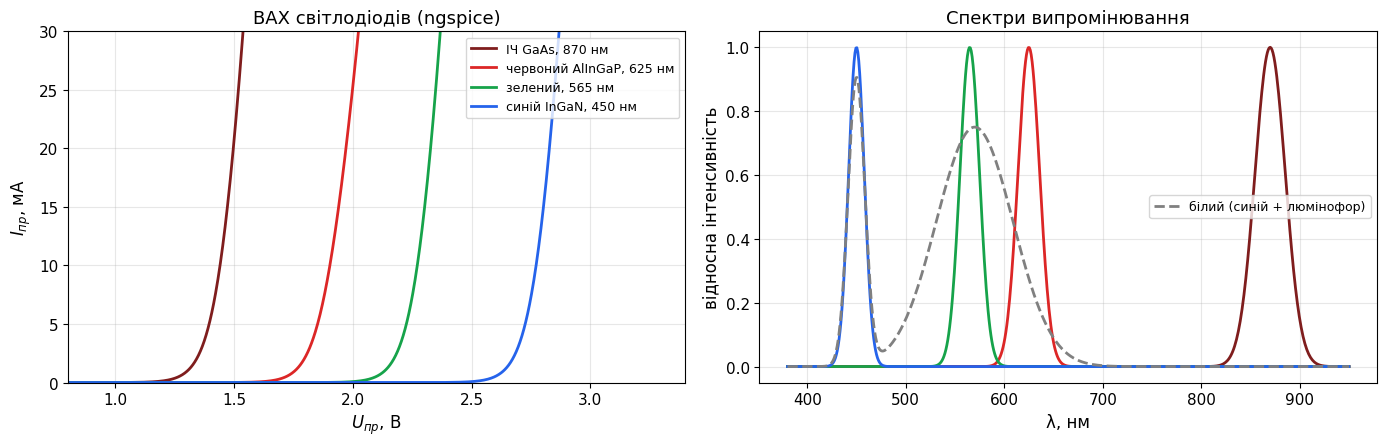

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
leds = [('LED_GAAS_IR', 'ІЧ GaAs, 870 нм', 870, '#7f1d1d'), ('LED_RED', 'червоний AlInGaP, 625 нм', 625, '#dc2626'),
        ('LED_GREEN', 'зелений, 565 нм', 565, '#16a34a'), ('LED_BLUE', 'синій InGaN, 450 нм', 450, '#2563eb')]
for model, lab, lam_nm, col in leds:
    c = Circuit('LED IV'); c.include(lib('diodes'))
    c.V('d', 'a', c.gnd, 0); c.D('1', 'a', c.gnd, model=model)
    an = c.simulator().dc(Vd=slice(0, 3.4, 0.002))
    U, I = np.array(an.sweep), -np.array(an.branches['vd'])
    axes[0].plot(U, I*1e3, color=col, label=lab)
    U10 = U[np.argmin(abs(I - 0.01))]
    print(f'{lab:28s}: U_пр(10 мА) = {U10:.2f} В;  hc/(qλ) = {1.24/(lam_nm*1e-3):.2f} В')
    lam = np.linspace(380, 950, 600)
    axes[1].plot(lam, np.exp(-((lam - lam_nm)/(0.025*lam_nm))**2), color=col)
axes[0].set_xlim(0.8, 3.4); axes[0].set_ylim(0, 30); axes[0].set_xlabel('$U_{пр}$, В'); axes[0].set_ylabel('$I_{пр}$, мА')
axes[0].set_title('ВАХ світлодіодів (ngspice)'); axes[0].legend(fontsize=9)
lam = np.linspace(380, 950, 600)
white = 0.9*np.exp(-((lam - 450)/12)**2) + 0.75*np.exp(-((lam - 570)/55)**2)
axes[1].plot(lam, white, color='gray', ls='--', label='білий (синій + люмінофор)')
axes[1].set_xlabel('λ, нм'); axes[1].set_ylabel('відносна інтенсивність'); axes[1].set_title('Спектри випромінювання'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

---
### 💡 Цікаво знати

<div style="background-color: #eff6ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #2563eb; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Синій світлодіод на InGaN, створений у 1990-х роках І. Акасакі, Х. Амано та С. Накамурою, відкрив шлях до білих світлодіодів і енергоефективного освітлення — за нього присуджено Нобелівську премію з фізики 2014 року. Ключовою проблемою було отримання p-типу GaN: акцептори Mg «пасивувалися» воднем, і лише відпал в азоті або опромінення електронами зробили їх активними.

</div>

---

# Оптрони <a class="anchor" id="optocoupler"></a>

**Оптрон** (оптопара, optocoupler) — прилад, у якому **випромінювач** (як правило, ІЧ-світлодіод на GaAs, 850–940 нм) і **фотоприймач** розміщені в одному світлонепроникному корпусі й пов'язані **оптичним каналом** (повітряний проміжок, прозорий ізолюючий компаунд, світловод). Електричний зв'язок між входом і виходом відсутній — сигнал передається світлом, тому оптрон забезпечує **гальванічну розв'язку** кіл з напругою ізоляції 2,5–10 кВ і опором ізоляції $10^{11}$–$10^{13}$ Ом. Він не пропускає в зворотному напрямку і не чутливий до синфазних завад.

**Типи оптронів за фотоприймачем:**

| Тип | Приймач | Особливості | Приклади |
|---|---|---|---|
| **Резисторний** | фоторезистор (CdS, CdSe) | аналоговий керований резистор, повільний, лінійний | VTL5C, АОР |
| **Діодний** | фотодіод (p-i-n) | лінійний, швидкий (до десятків МГц), малий CTR (0,1–0,5 %) | HCNR201, АОД |
| **Транзисторний** | фототранзистор | CTR 20–600 %, швидкодія 3–100 мкс | PC817, 4N35, TLP521, АОТ |
| **Дарлінгтона** | складений фототранзистор | CTR до 1000–5000 %, повільний | 4N32, 6N139 |
| **Цифровий (логічний)** | фотодіод + інтегральний підсилювач-формувач | швидкість 1–50 Мбіт/с | 6N137, HCPL-2601 |
| **Тиристорний / симісторний** | фототиристор, фотосимістор | керування мережевим навантаженням, вмикання в нулі напруги | MOC3021, MOC3041, АОУ |

**Основні параметри:** **коефіцієнт передачі струму** $CTR = I_{вих}/I_{вх}\cdot100\%$ (залежить від струму входу, температури і зменшується зі старінням світлодіода); напруга і опір ізоляції; прохідна ємність (0,5–2 пФ — визначає стійкість до швидких синфазних завад); часи вмикання/вимикання; максимальний вхідний струм і вихідна напруга.

**Застосування:** гальванічна розв'язка в колах зворотного зв'язку імпульсних блоків живлення (PC817 + TL431), розв'язка інтерфейсів (RS-485, CAN, MIDI), керування затворами силових ключів, твердотільні реле, датчики положення і швидкості (щілинні оптопари), розв'язка вимірювальних кіл у медичній техніці.

### ⚙️ PySpice: транзисторний оптрон — CTR і швидкодія <a class="anchor" id="spice-opto"></a>

Модель оптрона типу PC817: вхідний ІЧ-світлодіод `LED_GAAS_IR`; фотострум бази фототранзистора пропорційний струму світлодіода (джерело струму, кероване струмом, коефіцієнт 0,4 %); фототранзистор — 2N3904 з великою ємністю колектор–база 20 пФ (велика площа фоточутливого переходу). Праворуч — реакція на прямокутний вхідний сигнал: час перемикання сильно залежить від опору навантаження через ефект Міллера на ємності колектор–база.

In [10]:
def optocoupler(R_L_kOhm=1.0, I_F_mA=10):
    def make(R_L, src):
        c = Circuit('Optocoupler'); c.include(lib('diodes'))
        c.model('QPT', 'NPN', IS=1e-14, BF=200, VAF=80, CJC=20e-12, CJE=10e-12, TF=0.5e-9, IKF=0.1, RB=10)
        src(c)
        c.V('sense', 'ak', 'ac', 0); c.D('led', 'ac', c.gnd, model='LED_GAAS_IR')
        c.F('ph', c.gnd, 'b', 'Vsense', 0.004)            # фотострум бази = 0,4 % струму світлодіода
        c.V('cc', 'vcc', c.gnd, 5); c.R('L', 'vcc', 'c', R_L); c.BJT('pt', 'c', 'b', c.gnd, model='QPT')
        return c
    # (а) CTR: розгортка вхідного струму, вихід при Uке = 5 В (навантаження 1 Ом)
    c = make(1.0, lambda c: c.I('f', c.gnd, 'ak', 0))
    an = c.simulator().dc(If=slice(0.1e-3, 30e-3, 0.1e-3))
    IF = np.array(an.sweep); IC = (5 - np.array(an['c']))/1.0
    # (б) перехідний процес
    def pulse(c):
        c.PulseVoltageSource('in', 'in', c.gnd, initial_value=0, pulsed_value=5, delay_time=10e-6,
                             rise_time=50e-9, fall_time=50e-9, pulse_width=60e-6, period=1)
        c.R('f', 'in', 'ak', (5 - 1.25)/(I_F_mA*1e-3))
    c2 = make(R_L_kOhm*1e3, pulse)
    an2 = c2.simulator().transient(step_time=50e-9, end_time=140e-6, max_time=100e-9)
    t = np.array(an2.time)*1e6; vin = np.array(an2['in']); vc = np.array(an2['c'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    axes[0].plot(IF*1e3, IC/IF*100, color='#7c3aed'); axes[0].set_xlabel('$I_F$, мА'); axes[0].set_ylabel('CTR, %')
    axes[0].set_title('Коефіцієнт передачі струму CTR = $I_К/I_F$')
    axes[1].plot(t, vin, color='gray', lw=1, label='вхід (керування світлодіодом)')
    axes[1].plot(t, vc, color='#dc2626', lw=2, label='вихід (колектор)')
    axes[1].set_xlabel('t, мкс'); axes[1].set_ylabel('U, В'); axes[1].legend(fontsize=9, loc='center right')
    axes[1].set_title(f'Перемикання: $I_F$ = {I_F_mA} мА, $R_L$ = {R_L_kOhm} кОм')
    plt.tight_layout(); plt.show()
    lo, hi = vc.min(), 5.0
    def cross(level, after, rising):
        idx = np.where((t > after) & ((vc > level) if rising else (vc < level)))[0]
        return t[idx[0]] if len(idx) else np.nan
    t_on = cross(lo + 0.1*(hi - lo), 10, False) - 10
    t_off = cross(lo + 0.9*(hi - lo), 70, True) - 70
    sat = 'транзистор насичується' if lo < 0.4 else f'транзистор НЕ насичується (U_вих.min = {lo:.2f} В) — замалий I_F або великий R_L'
    print(f'CTR при {I_F_mA} мА ≈ {np.interp(I_F_mA*1e-3, IF, IC/IF)*100:.0f} %;  {sat}')
    print(f'Час вмикання (до 10 %) ≈ {t_on:.1f} мкс, час вимикання (до 90 %) ≈ {t_off:.1f} мкс')

interact(optocoupler,
         R_L_kOhm=widgets.SelectionSlider(options=[0.1, 0.3, 1.0, 3.0, 10.0], value=1.0, description='$R_L$, кОм', continuous_update=False),
         I_F_mA=widgets.SelectionSlider(options=[2, 5, 10, 20], value=10, description='$I_F$, мА', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='$R_L$, кОм', index=2, options=(0.1…

---
### ⚡ Практичне застосування: Оптрон у зворотному зв'язку імпульсного блока живлення

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

У зарядних пристроях і блоках живлення з мережі вихідна напруга (низьковольтна, безпечна сторона) має керувати ШІМ-контролером на первинній (мережевій) стороні без гальванічного зв'язку. Регульований стабілітрон TL431 порівнює вихідну напругу з опорною 2,5 В і змінює струм світлодіода оптрона PC817; фототранзистор на первинній стороні зменшує сигнал на вході контролера — коефіцієнт заповнення ШІМ зменшується. Розкид і старіння CTR компенсуються петлею зворотного зв'язку.

</div>

---
### ✅ Питання для самоперевірки: Оптоелектронні прилади

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому кремнієві фотодіоди не чутливі до випромінювання з довжиною хвилі 1,55 мкм?</summary>

> **Відповідь:** Енергія фотона $1{,}24/1{,}55 = 0{,}8$ еВ менша за ширину забороненої зони кремнію 1,12 еВ ($\lambda_{гр}$ ≈ 1,1 мкм): фотон не може створити електронно-діркову пару. Для 1,3–1,55 мкм використовують Ge або InGaAs.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чим зумовлена висока чутливість і водночас інерційність фоторезисторів?</summary>

> **Відповідь:** Обидві властивості визначає великий час життя носіїв $\tau$: за час життя носій багато разів проходить між електродами (фотострумове підсилення $\tau/t_{пр}$ ≫ 1), але й концентрація носіїв встановлюється і спадає з тією самою постійною часу $\tau$ (мілісекунди).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як залежать $U_{хх}$ і $I_{кз}$ фотодіода від освітленості?</summary>

> **Відповідь:** $I_{кз} = I_ф$ — лінійно; $U_{хх} = m\varphi_T\ln(I_ф/I_0 + 1)$ — логарифмічно: при збільшенні освітленості в 10 разів $U_{хх}$ зростає лише на ≈ 60–70 мВ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Навіщо на фотодіод подають зворотну напругу?</summary>

> **Відповідь:** Зворотне зміщення розширює ОПЗ (більше пар розділяється полем, а не дифузією), зменшує бар'єрну ємність і час відгуку, забезпечує лінійність струму від світлового потоку. Ціна — темновий струм.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Чому світлодіоди не роблять з кремнію і чому червоні світлодіоди мають меншу пряму напругу, ніж сині?</summary>

> **Відповідь:** Кремній непрямозонний — рекомбінація відбувається з участю фононів і майже без випромінювання. Пряма напруга близька до $E_g/q$ = енергії фотона: 1,9–2 еВ для червоного (625 нм) і 2,7 еВ для синього (450 нм).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 6.</b> Що таке CTR оптрона і чому при проектуванні закладають запас?</summary>

> **Відповідь:** Відношення вихідного струму фототранзистора до вхідного струму світлодіода. CTR має технологічний розкид (наприклад, PC817 — 50–600 %), падає з температурою і зменшується при старінні світлодіода (на 20–50 % за десятки тисяч годин), тому вхідний струм обирають так, щоб транзистор насичувався навіть при мінімальному CTR.

</details>

---
### 📝 Задачі для самостійного розв'язання: Оптоелектронні прилади


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Визначте червону межу фотоефекту для Si ($E_g$ = 1,12 еВ), GaAs (1,42 еВ) та InGaAs (0,75 еВ).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\lambda_{гр} = 1{,}24/E_g$: Si — 1,11 мкм, GaAs — 0,87 мкм, InGaAs — 1,65 мкм.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Фотодіод з $I_0$ = 2 нА, $m$ = 1,1 освітлено так, що $I_ф$ = 60 мкА. Знайдіть напругу холостого ходу при 300 К. Як вона зміниться при зменшенні освітленості в 10 разів?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U_{хх} = 1{,}1\cdot0{,}0259\cdot\ln(3\cdot10^4) \approx 0.293$ В; при $I_ф$ = 6 мкА — $0.228$ В (менше на $m\varphi_T\ln10 \approx 65$ мВ).

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Сонячний елемент має $U_{хх}$ = 0,63 В, $I_{кз}$ = 9 А, коефіцієнт заповнення 0,78, площа 0,0243 м². Знайдіть максимальну потужність і ККД при 1000 Вт/м².

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $P_{max} = FF\cdot U_{хх}I_{кз} = 0{,}78\cdot0{,}63\cdot9 \approx 4{,}4$ Вт; ККД $= 4{,}4/(1000\cdot0{,}0243) \approx 18$ %.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Оптрон PC817 має мінімальний CTR = 50 %. Вихід — фототранзистор з навантаженням 4,7 кОм на 5 В. Який мінімальний струм світлодіода гарантує насичення?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_{К.нас} \approx (5 - 0{,}2)/4700 \approx 1$ мА; $I_F \ge I_К/CTR_{min} = 2$ мА — з запасом на старіння обирають 3–5 мА.

</details>

---

## 📌 Підсумок лекції 12: Оптоелектронні прилади <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Прилад | Фізичний ефект | Ключові характеристики | Застосування |
|---|---|---|---|
| **Фоторезистор** | фотопровідність | $R_т/R_с$, люкс-омна характеристика, τ = мс | датчики освітленості, фотореле |
| **Фотодіод** | поділ пар полем p-n переходу | $S_I$, темновий струм, $C_{бар}$, лінійність | фотометрія, оптичний зв'язок |
| **Сонячний елемент** | фотогальванічний режим | $U_{хх}$, $I_{кз}$, FF, ККД, MPP | фотоенергетика |
| **Світлодіод** | інжекційна електролюмінесценція | λ ≈ 1,24/$E_g$, $I_V$, лм/Вт | індикація, освітлення, ІЧ-зв'язок |
| **Оптрон** | випромінювач + приймач з оптичним зв'язком | CTR, $U_{із}$, швидкодія | гальванічна розв'язка, SSR |

**Головні висновки.** (1) Фоточутливість напівпровідника обмежена червоною межею $\lambda_{гр}$ = 1,24/$E_g$. (2) Фоторезистори чутливі, але інерційні — все визначає час життя носіїв. (3) Фотодіод у фотодіодному режимі дає струм, пропорційний світловому потоку, у фотогальванічному — сам генерує енергію; швидкодію визначає $R_нC_{бар}$. (4) Колір світлодіода задається шириною забороненої зони прямозонного матеріалу; білий СД — синій кристал з люмінофором. (5) Оптрон передає сигнал світлом і забезпечує гальванічну розв'язку; його головний параметр — CTR, який треба закладати з запасом.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 11. Тиристорні прилади](Лекція_11_Тиристорні_прилади.ipynb) &nbsp;|&nbsp; [Лекція 13. Прилади із зарядовим зв'язком, терморезистори та варістори](Лекція_13_ПЗЗ_терморезистори_варістори.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*